# Relations II - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-2/relations-2.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Reflexive, Symmetric, Transitive
(Several arrow diagrams for the examples.)

Let the set $A = \{0,1,2,3\}$. Define the relation
$$
    R = \{(0,0),(0,1),(0,3),(1,0),(1,1),(2,2),(3,0),(3,3)\}. 
$$
It has the following arrow diagram.

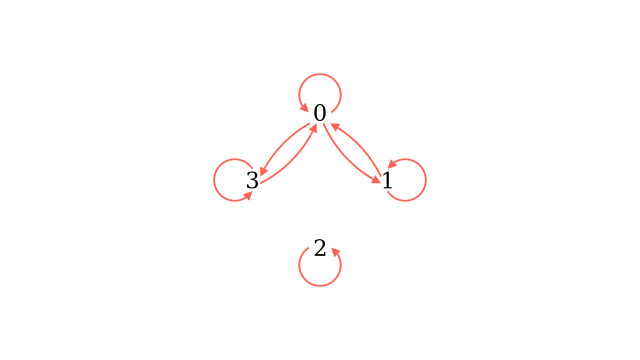

In [25]:
%%generate_image rst_1 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*DOWN),
            (0, 3): ((1.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*UP),
            (1, 0): ((0.5*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*RIGHT),
            (3, 0): ((0.5*ARROW_START_SHIFT)*DOWN, (0.5*ARROW_START_SHIFT)*LEFT)
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

Let the set $A = \{0,1,2,3\}$. Define the relation
$$
    S = \{(0,0),(0,2),(0,3),(2,3)\}
$$
on $A$, which has the following arrow diagram.

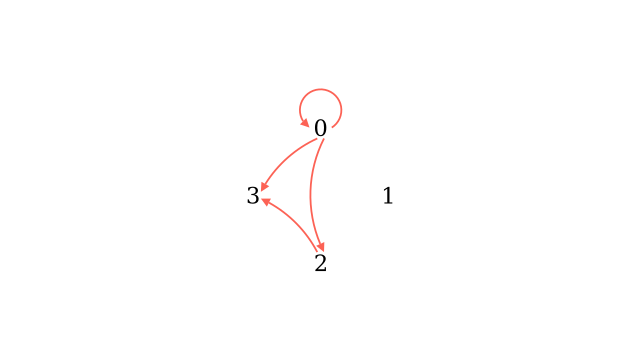

In [26]:
%%generate_image rst_2 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 2): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*RIGHT),
            (0, 3): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*UP),
            (2, 3): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*DOWN),
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

### Equivalence Relations

Consider $A = \{0, 1, 2, 3\}$ and define a relation $R$ on $A$ by
$$
    R = \{(0,0), (1,1), (2,2), (3,3)\}
$$

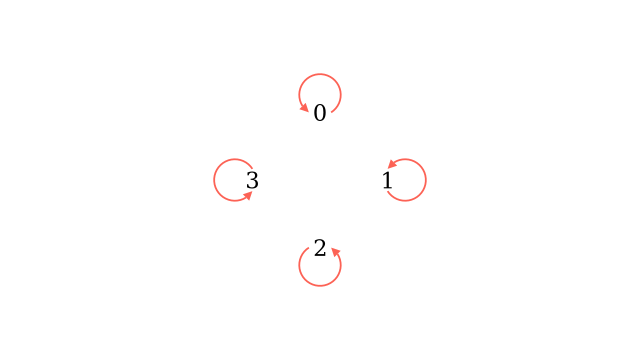

In [17]:
%%generate_image equiv-rel_1 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {}  # Nothing :p
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

Consider $A = \{0, 1, 2, 3\}$ and define a relation $R$ on $A$ by
$$
    \begin{align*}
        R &= \{(0, 0), (0, 1), (0, 2), (1, 0), (1, 1),\\
        &\quad\quad(1, 2), (2, 0), (2, 1), (2, 2), (3, 3)\}
    \end{align*}
$$

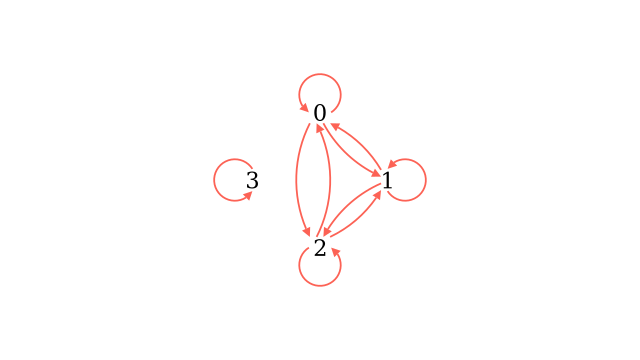

In [16]:
%%generate_image equiv-rel_2 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*UP),
            (0, 2): ((1.5*ARROW_START_SHIFT)*LEFT, (1.5*ARROW_START_SHIFT)*LEFT),
            (1, 0): ((1.5*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*RIGHT),
            (1, 2): ((0.5*ARROW_START_SHIFT)*DOWN, (0.5*ARROW_START_SHIFT)*RIGHT),
            (2, 0): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*LEFT),
            (2, 1): ((1.5*ARROW_START_SHIFT)*RIGHT, (1.5*ARROW_START_SHIFT)*DOWN)
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

### Equivalence Classes

The equivalence relation
$$
    R = \{(0,0), (0,4), (1,1), (1,3), (2,2), (3,1), (3,3), (4,0), (4,4), (5,5)\}
$$
defined on the set $A = \{0,1,2,3,4,5\}$.

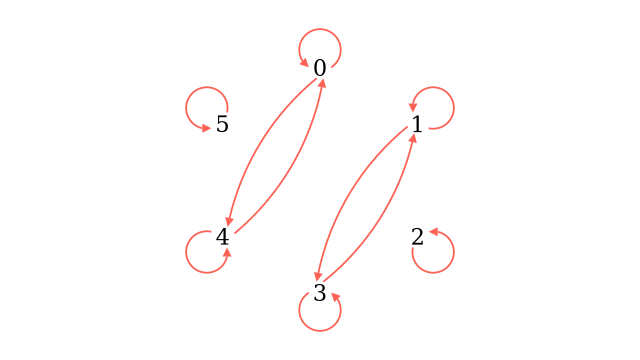

In [34]:
%%generate_image equiv-class RelationDiagram --temp-dir temp
    
FONT_SIZE = 36

RADIUS = 2.5  # Radius of hexagon

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3", "4", "5"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_corner(DOWN+LEFT) + ELEMENT_POS_SHIFT*(UP+LEFT),
            2: elements[2].get_corner(UP+LEFT) + ELEMENT_POS_SHIFT*(DOWN+RIGHT),
            3: elements[3].get_top() + ELEMENT_POS_SHIFT*UP,
            4: elements[4].get_corner(UP+RIGHT) + ELEMENT_POS_SHIFT*(DOWN+RIGHT),
            5: elements[5].get_corner(DOWN+RIGHT) + ELEMENT_POS_SHIFT*(UP+LEFT)
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*(UP+RIGHT), start_angle=-np.pi/2, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*(DOWN+RIGHT), start_angle=-np.pi, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[4].get_center() + 0.25*(DOWN+LEFT), start_angle=np.pi/2, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[5].get_center() + 0.25*(UP+LEFT), start_angle=0, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 4): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*(UP+LEFT)),
            (1, 3): ((0.5*ARROW_START_SHIFT)*(UP+LEFT), (0.5*ARROW_START_SHIFT)*LEFT),
            (3, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*(DOWN+RIGHT)),
            (4, 0): ((0.5*ARROW_START_SHIFT)*(DOWN+RIGHT), (0.5*ARROW_START_SHIFT)*RIGHT),
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 6
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

### Divides Relation

The divides relation on $A = \{1, 2, 3, 9, 18\}$ as a directed graph.

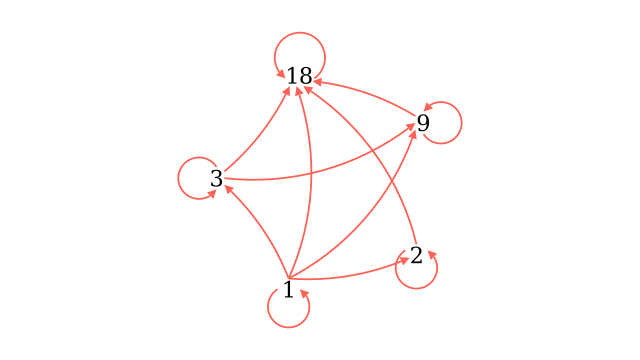

In [13]:
%%generate_image divides_directed-graph RelationDiagram

FONT_SIZE = 36

RADIUS = 2.5  # Radius of pentagon

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements_orig = ["18", "9", "2", "1", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements_orig]
        arrange_circular(*elements, clockwise=True, radius=RADIUS, offset=np.pi/12)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_top() + ELEMENT_POS_SHIFT*UP,
            4: elements[4].get_right() + ELEMENT_POS_SHIFT*RIGHT
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.45),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=-3*np.pi/4, angle=-3*np.pi/2, radius=0.35).flip(LEFT),
            Arc(arc_center=elements[3].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[4].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        # inter_element_relations = {}
        # for i, m in enumerate(elements_orig):
        #     for j, n in enumerate(elements_orig):
        #         if m != n and int(n) % int(m) == 0:
        #             inter_element_relations[(i, j)] = (0,0)
        # print(inter_element_relations)
        inter_element_relations = {
            (1, 0): ((1*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*(0.5*UP+1.25*RIGHT)),
            (2, 0): (0, (0.5*ARROW_START_SHIFT)*RIGHT), 
            (3, 0): (0, (0.5*ARROW_START_SHIFT)*LEFT),
            (3, 1): (0, (1*ARROW_START_SHIFT)*DOWN),
            (3, 2): (0, (1*ARROW_START_SHIFT)*(2*DOWN+LEFT)),
            (3, 4): (0, (1*ARROW_START_SHIFT)*DOWN),
            (4, 0): ((1*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*LEFT),
            (4, 1): (0, 0)
        }
                    
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 6
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

As Hasse diagram.

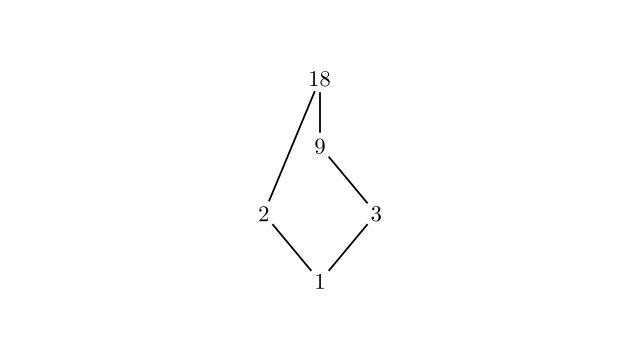

In [15]:
%%generate_image divides_hasse HasseDiagram


class HasseDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["18", "9", "2", "1", "3"]
        # relations = []
        # for m in elements:
        #     for n in elements:
        #         if m != n and int(n) % int(m) == 0:
        #             relations.append((m, n))
        # print(relations)
        relations = [
            ('9', '18'), 
            ('2', '18'), 
            # ('1', '18'), 
            # ('1', '9'), 
            ('1', '2'), 
            ('1', '3'), 
            # ('3', '18'), 
            ('3', '9')
        ]
        
        # Create the Hasse graph
        graph = HasseGraph(
            elements,
            relations,
            label_colour=BLACK,
            edge_config={
                "stroke_color": BLACK
            },
            layout_config={
                "scale_x": 2.5,
                "scale_y": 0.75,
            }
        )
        self.add(graph)

### Subset Relation
(As a Hasse diagram)

Helper function to generate a power set.

In [5]:
from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))

Actual scene.

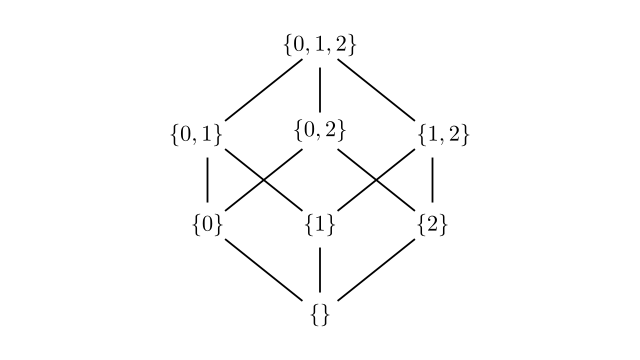

In [7]:
%%generate_image subset-as-hasse HasseDiagram


class HasseDiagram(Scene):
    def construct(self):
        # Create subsets
        elements = ["0", "1", "2"]
        subsets = powerset(elements)

        # Create vertices and edges
        vertices = [
            rf"\{{{', '.join(s)}\}}" for s in subsets 
        ]
        
        # edges = []
        # for i, s in enumerate(subsets):
        #     for j, t in enumerate(subsets):
        #         if s == t:
        #             continue
        #         if set(s).issubset(set(t)):
        #             edges.append((vertices[i], vertices[j]))
        # print(edges)
        edges = [
            ("\\{\\}", "\\{0\\}"),
            ("\\{\\}", "\\{1\\}"),
            ("\\{\\}", "\\{2\\}"),
            ("\\{0\\}", "\\{0, 1\\}"),
            ("\\{0\\}", "\\{0, 2\\}"),
            ("\\{1\\}", "\\{0, 1\\}"),
            ("\\{1\\}", "\\{1, 2\\}"),
            ("\\{2\\}", "\\{0, 2\\}"),
            ("\\{2\\}", "\\{1, 2\\}"),
            ("\\{0, 1\\}", "\\{0, 1, 2\\}"),
            ("\\{0, 2\\}", "\\{0, 1, 2\\}"),
            ("\\{1, 2\\}", "\\{0, 1, 2\\}"),
        ]
        
        # Create the Hasse graph
        graph = HasseGraph(
            vertices,
            edges,
            label_colour=BLACK,
            label_buff=0.5,
            perform_correction=False,
            edge_config={
                "stroke_color": BLACK
            },
            layout_config={
                "scale_x": 2.5,
                "scale_y": 1,
            }
        )
        # print(list(graph.edges.keys()))
        
        self.add(graph)

        # Adjust some of the labels
        graph[r"\{0, 1\}"].shift(0.25*LEFT)
        graph[r"\{0, 2\}"].shift(0.1*UP)
        graph[r"\{1, 2\}"].shift(0.25*RIGHT)

### Divides on a Subset of $\mathbb{N}$

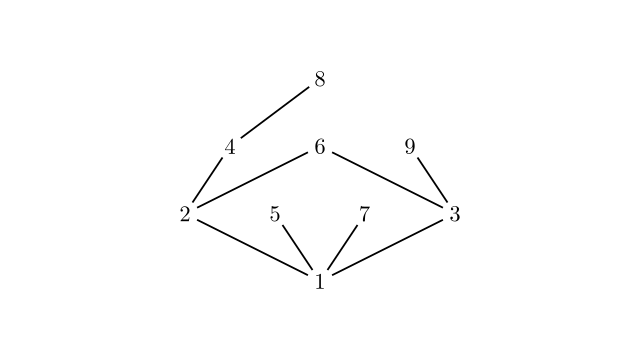

In [30]:
%%generate_image divides-as-hasse HasseDiagram


class HasseDiagram(Scene):
    def construct(self):
        # Create vertices and edges
        vertices = [
            i for i in range(1, 10)
        ]
        
        # edges = []
        # for i in vertices:
        #     for j in vertices:
        #         if i != j and j % i == 0:
        #             edges.append((i,j))
        edges = [(1, 2), (1, 3), (1, 5), (1, 7), (2, 4), (2, 6), (3, 6), (3, 9), (4, 8)]
        
        # Create the Hasse graph
        graph = HasseGraph(
            vertices,
            edges,
            label_colour=BLACK,
            perform_correction=True,
            edge_config={
                "stroke_color": BLACK
            },
            layout_config={
                "scale_x": 2,
                "scale_y": 0.75,
            }
        )
        # print(list(graph.edges.keys()))
        
        self.add(graph)

### TODO